In [110]:
print("importing...")
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("imported!")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 120
})

DATA_PATH = r"C:\Users\Jorick\code\mosaic-ms\master\Mosaic-MS\snakemake\effect_of_network\results\final_scores_summary.csv"

print("Libraries imported successfully.")

importing...
imported!
Libraries imported successfully.


In [111]:
df = pd.read_csv(DATA_PATH)

In [112]:
def accuracy_plot(full_df, graph_type, use_average):
    df = full_df[full_df["graph_type"] == graph_type]
    df = df[df["use_average_similarity"] == use_average]
    
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten 2D array of axes into 1D array for easy iteration

    # Define similarity types and quality categories
    similarity_types = ['cos', 'modcos', 'spec2vec', 'ms2deepscore']
    categories = ['good', 'miss', 'poor']
    colors = ['#2ca02c', '#ff7f0e', '#d62728']  # Optional distinct colors: Green, Orange, Red

    # 2. Iterate and plot each similarity type
    for idx, sim_type in enumerate(similarity_types):
        ax = axes[idx]
        
        # Filter for base graph and current similarity type
        sub_df = df[df['similarity_type'] == sim_type]
        
        if not sub_df.empty:
            # Index by x-axis variable
            df_indexed = sub_df.set_index('max_component_size')[categories].fillna(0).sort_index()
            
            # Plot stacked area
            ax.stackplot(
                df_indexed.index, 
                [df_indexed[cat] for cat in categories], 
                labels=['Good', 'Miss', 'Poor'],
                colors=colors,
                alpha=0.8
            )
        
        # Titles & Inversion
        ax.set_title(f'{sim_type}', fontsize=12)
        ax.grid(True, linestyle='-', alpha=0.5)

    # 3. Axis labels for shared grid
    fig.supxlabel('k', fontsize=12, y=0.10)
    fig.supylabel('Number of Annotations', fontsize=12, x=0.05)

    # Single unified legend for all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Category', loc='upper right', bbox_to_anchor=(0.98, 0.65))
    plt.tight_layout(rect=[0.03, 0.03, 0.88, 0.95])
    plt.gca().invert_xaxis()
    plt.ylim(bottom=0)
    plt.ylim(top=2100)
    plt.show()

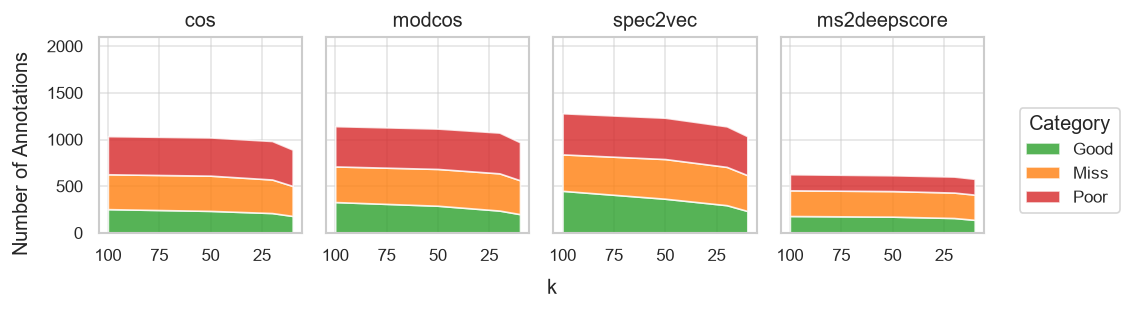

In [113]:
accuracy_plot(df, "base", True) 

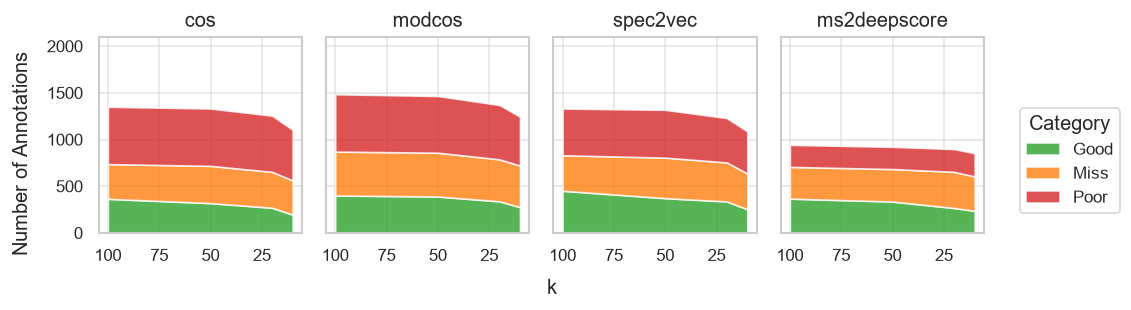

In [114]:
accuracy_plot(df, "base", False) 

In [115]:
def line_accuracy_plot(full_df, graph_type):
    df = full_df[full_df["graph_type"] == graph_type]
    
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten 2D array of axes into 1D array for easy iteration

    # Define similarity types and quality categories
    similarity_types = ['cos', 'modcos', 'spec2vec', 'ms2deepscore']

    # 2. Iterate and plot each similarity type
    for idx, sim_type in enumerate(similarity_types):
        ax = axes[idx]
        
        # Filter for base graph and current similarity type
        sub_df = df[df['similarity_type'] == sim_type]
        
        if not sub_df.empty:
            # Index by x-axis variable
            # Plot stacked area
            sub_df0 = sub_df[sub_df["use_average_similarity"] == False]
            sub_df1 = sub_df[sub_df["use_average_similarity"] == True]
            ax.plot(
                sub_df0['max_component_size'], 
                (sub_df0["good"]) / (sub_df0["good"] + sub_df0["miss"] + sub_df0["poor"]), label="default"
            )
            ax.plot(
                sub_df1['max_component_size'], 
                (sub_df1["good"]) / (sub_df1["good"] + sub_df1["miss"] + sub_df1["poor"]), label="average"
            )
        
        # Titles & Inversion
        ax.set_title(f'{sim_type}', fontsize=12)
        ax.grid(True, linestyle='-', alpha=0.5)

    fig.supxlabel('max comp size', fontsize=12, y=0.10)
    fig.supylabel('Accuracy (good / total_annotated)', fontsize=12, x=0.05)
    plt.tight_layout(rect=[0.03, 0.03, 0.88, 0.95])
    plt.legend()
    plt.show()

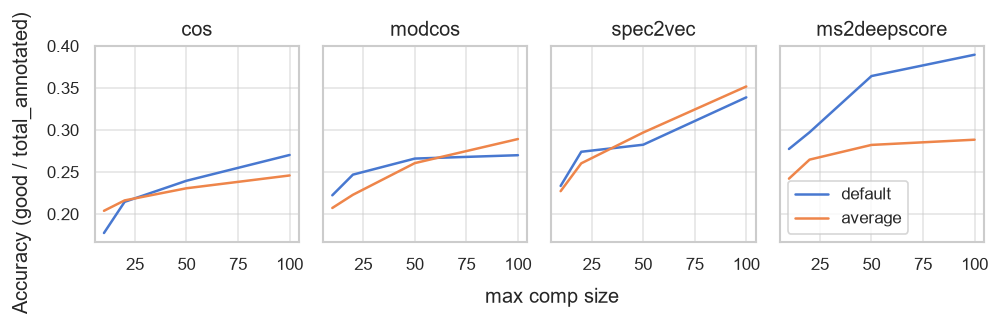

In [116]:
line_accuracy_plot(df, "base")

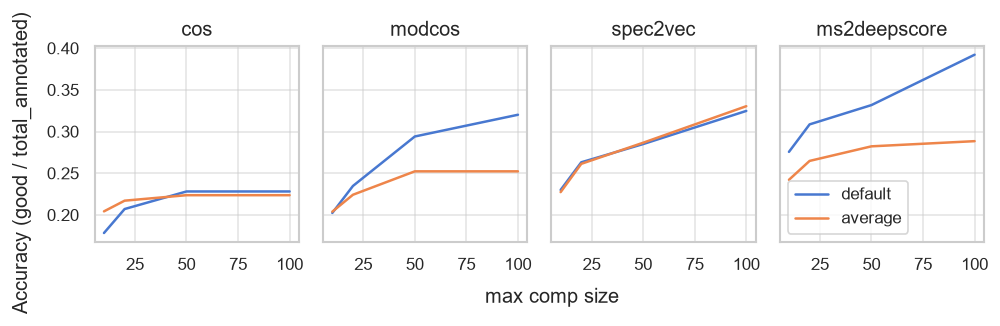

In [117]:
line_accuracy_plot(df, "threshold")

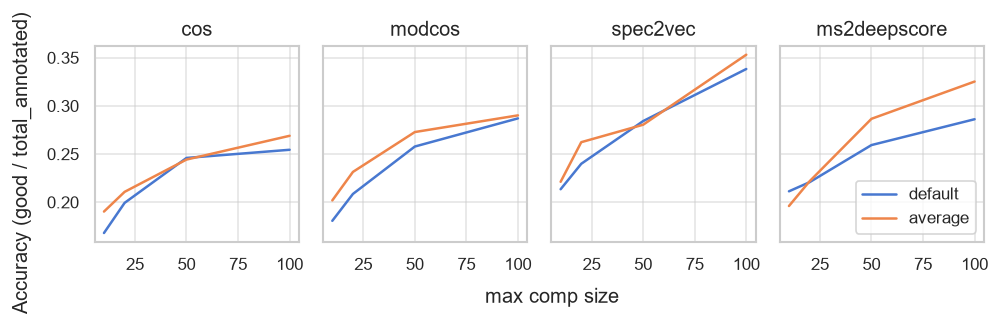

In [118]:
line_accuracy_plot(df, "rescued")